# Метод опорных векторов (SVM)

В этом ноутбуке разберём **метод опорных векторов (Support Vector Machines, SVM)** для бинарной классификации.

**Цели ноутбука:**
- Понять геометрическую идею SVM и зазора (margin).
- Рассмотреть мягкий зазор и hinge-loss.
- Реализовать **линейный SVM с нуля** (градиентный спуск по hinge-loss).
- Сравнить с `SVC`/`LinearSVC` из `sklearn` и визуализировать границу решений.

---

**Содержание:** Идея SVM и margin → Мягкий зазор, hinge-loss → Реализация с нуля → Сравнение с sklearn.


## Идея SVM и максимальный зазор

Рассмотрим бинарную классификацию с метками $y_i \in \{-1, +1\}$ и объектами $x_i \in \mathbb{R}^d$.
Линейный классификатор имеет вид:
$$
f(x) = \operatorname{sign}(w^T x + b).
$$

SVM ищет такую гиперплоскость, которая **максимизирует зазор** между классами.
Геометрически зазор пропорционален $1 / \lVert w \rVert$.

В жёстком (hard-margin) случае, когда выборка линейно разделима, классический SVM решает задачу:
$$
\min_{w, b} \frac{1}{2} \lVert w \rVert^2 \quad \text{при условии} \quad y_i (w^T x_i + b) \ge 1 \; \forall i.
$$
Это максимизирует зазор при условии корректной классификации всех точек.


## Мягкий зазор и hinge-loss

На реальных данных классы часто **неразделимы** линейно. SVM с мягким зазором вводит штрафы за ошибки через slack-переменные, что приводит к оптимизационной задаче вида:
$$
\min_{w, b} \; \frac{1}{2} \lVert w \rVert^2 + C \sum_{i=1}^N \xi_i,
$$
при ограничениях
$$
y_i (w^T x_i + b) \ge 1 - \xi_i, \quad \xi_i \ge 0.
$$

Эквивалентно это можно записать через **hinge-loss**:
$$
\min_{w, b} \; \frac{1}{2} \lVert w \rVert^2 + C \sum_{i=1}^N \max\bigl(0, 1 - y_i (w^T x_i + b)\bigr).
$$

В этом ноутбуке мы реализуем упрощённый градиентный спуск по этой функции (без ядровых трюков, только линейный случай).


## Синтетические данные

Возьмём двумерные данные `make_moons` с небольшим шумом, чтобы визуально посмотреть на разделяющую прямую линейного SVM и нелинейную границу у SVM с RBF-ядром из `sklearn`.


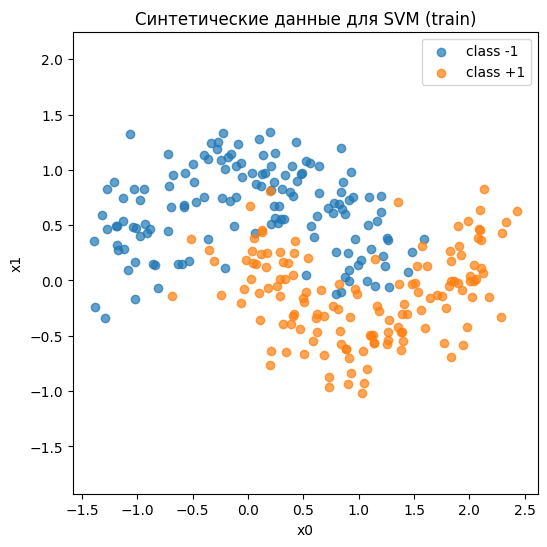

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

X, y_bin = make_moons(n_samples=400, noise=0.25, random_state=42)
X_train, X_test, y_train_bin, y_test_bin = train_test_split(X, y_bin, test_size=0.3, random_state=42)

# Преобразуем метки в {-1, +1} для нашей реализации
y_train = np.where(y_train_bin == 1, 1, -1)
y_test = np.where(y_test_bin == 1, 1, -1)

# Масштабируем признаки
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(X_train[y_train == -1, 0], X_train[y_train == -1, 1], color="tab:blue", alpha=0.7, label="class -1")
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color="tab:orange", alpha=0.7, label="class +1")
plt.title("Синтетические данные для SVM (train)")
plt.xlabel("x0")
plt.ylabel("x1")
plt.legend()
plt.axis("equal")
plt.show()


## Линейный SVM с нуля (градиентный спуск)

Реализуем простой линейный SVM, минимизирующий функцию:
$$
L(w, b) = \frac{1}{2} \lVert w \rVert^2 + C \sum_{i=1}^N \max(0, 1 - y_i (w^T x_i + b)).
$$

Будем использовать **стохастический градиентный спуск (SGD)**:
- на каждой итерации берём мини-батч (или один объект),
- считаем субградиент по $w$ и $b$,
- делаем шаг в направлении, уменьшающем функцию.

Это обучающий пример, чтобы увидеть связь между теорией и кодом.


In [2]:
class LinearSVMScratch:
    def __init__(self, C: float = 1.0, lr: float = 0.01, n_epochs: int = 1000):
        self.C = C
        self.lr = lr
        self.n_epochs = n_epochs
        self.w_ = None
        self.b_ = None

    def fit(self, X: np.ndarray, y: np.ndarray):
        X = np.asarray(X)
        y = np.asarray(y)
        n_samples, n_features = X.shape

        self.w_ = np.zeros(n_features)
        self.b_ = 0.0

        for epoch in range(self.n_epochs):
            # Перемешаем индексы для простого SGD
            idx = np.random.permutation(n_samples)
            for i in idx:
                x_i = X[i]
                y_i = y[i]
                margin = y_i * (np.dot(self.w_, x_i) + self.b_)
                if margin >= 1:
                    # Вне полосы зазора: только регуляризация
                    grad_w = self.w_
                    grad_b = 0.0
                else:
                    # В полосе зазора или ошибка: добавляется градиент hinge-loss
                    grad_w = self.w_ - self.C * y_i * x_i
                    grad_b = -self.C * y_i

                self.w_ -= self.lr * grad_w
                self.b_ -= self.lr * grad_b

        return self

    def decision_function(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X)
        return X @ self.w_ + self.b_

    def predict(self, X: np.ndarray) -> np.ndarray:
        scores = self.decision_function(X)
        return np.where(scores >= 0, 1, -1)


svm_lin = LinearSVMScratch(C=1.0, lr=0.01, n_epochs=200)
svm_lin.fit(X_train_scaled, y_train)

y_pred_train = svm_lin.predict(X_train_scaled)
y_pred_test = svm_lin.predict(X_test_scaled)

train_acc = (y_pred_train == y_train).mean()
test_acc = (y_pred_test == y_test).mean()

print(f"Linear SVM scratch train accuracy: {train_acc:.3f}")
print(f"Linear SVM scratch test  accuracy: {test_acc:.3f}")


Linear SVM scratch train accuracy: 0.843
Linear SVM scratch test  accuracy: 0.825


## Визуализация линейного SVM (scratch)

Построим разделяющую прямую $w^T x + b = 0$ в исходном пространстве (для этого применим обратное масштабирование к нескольким точкам на прямой). Для `make_moons` линейный SVM не сможет идеально разделить классы, но мы увидим направление, которое он выбирает.


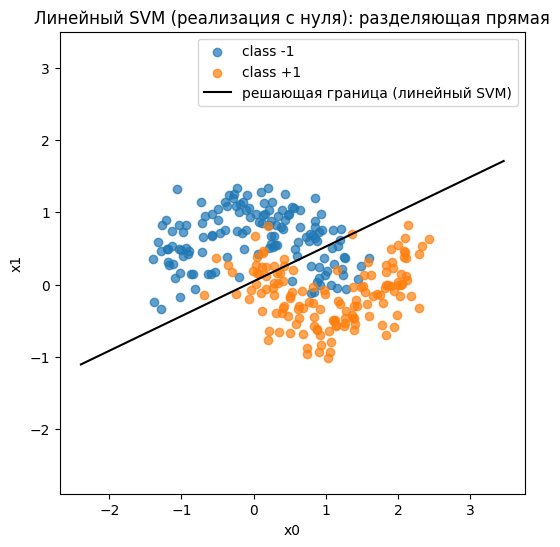

In [3]:
# Построим линию решения в стандартизованном пространстве
x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
xs = np.linspace(x_min, x_max, 200)

# Для каждой x0 найдём x1 из уравнения w^T x + b = 0 в стандартизованных координатах
# x_std = (x - mean) / scale, поэтому аккуратно выразим линию в исходных координатах.
mean = scaler.mean_
scale = scaler.scale_

w = svm_lin.w_ / scale  # пересчёт в исходный масштаб
b = svm_lin.b_ - np.dot(svm_lin.w_, mean / scale)

ys = -(w[0] * xs + b) / w[1]

plt.figure(figsize=(6, 6))
plt.scatter(X_train[y_train == -1, 0], X_train[y_train == -1, 1], color="tab:blue", alpha=0.7, label="class -1")
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color="tab:orange", alpha=0.7, label="class +1")
plt.plot(xs, ys, color="k", label="решающая граница (линейный SVM)")
plt.title("Линейный SVM (реализация с нуля): разделяющая прямая")
plt.xlabel("x0")
plt.ylabel("x1")
plt.legend()
plt.axis("equal")
plt.show()


## SVM из `sklearn`: линейный и с RBF-ядром

В `sklearn` есть несколько реализаций SVM:
- `LinearSVC` — линейный SVM (эффективен для больших выборок и признаков),
- `SVC` — "ядровый" SVM, поддерживающий RBF-, полиномиальное и другие ядра.

Мы посмотрим на:
- линейный SVM (`LinearSVC`),
- SVM с RBF-ядром (`SVC(kernel="rbf")`).


LinearSVC (sklearn):
  train accuracy: 0.854
  test  accuracy: 0.817

SVC (rbf kernel, sklearn):
  train accuracy: 0.929
  test  accuracy: 0.908


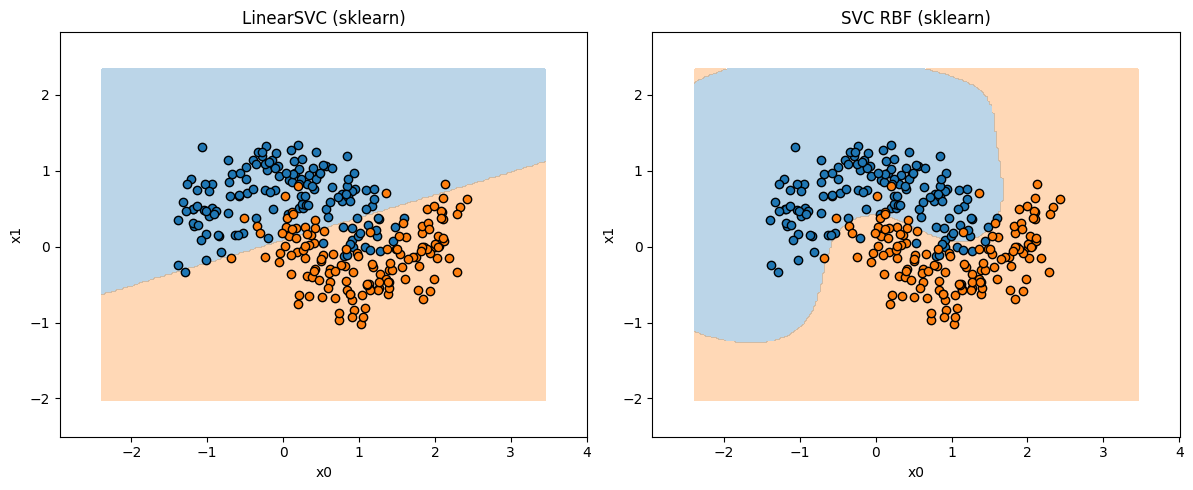

In [4]:
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import accuracy_score

# Линейный SVM из sklearn
lin_clf = LinearSVC(C=1.0, random_state=42)
lin_clf.fit(X_train_scaled, y_train_bin)

y_pred_train_lin = lin_clf.predict(X_train_scaled)
y_pred_test_lin = lin_clf.predict(X_test_scaled)

print("LinearSVC (sklearn):")
print(f"  train accuracy: {accuracy_score(y_train_bin, y_pred_train_lin):.3f}")
print(f"  test  accuracy: {accuracy_score(y_test_bin, y_pred_test_lin):.3f}")

# SVM с RBF-ядром
rbf_clf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
rbf_clf.fit(X_train_scaled, y_train_bin)

y_pred_train_rbf = rbf_clf.predict(X_train_scaled)
y_pred_test_rbf = rbf_clf.predict(X_test_scaled)

print("\nSVC (rbf kernel, sklearn):")
print(f"  train accuracy: {accuracy_score(y_train_bin, y_pred_train_rbf):.3f}")
print(f"  test  accuracy: {accuracy_score(y_test_bin, y_pred_test_rbf):.3f}")

# Визуализируем границы решений обоих вариантов
x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200),
)
grid = np.c_[xx.ravel(), yy.ravel()]
grid_scaled = scaler.transform(grid)

zz_lin = lin_clf.predict(grid_scaled).reshape(xx.shape)
zz_rbf = rbf_clf.predict(grid_scaled).reshape(xx.shape)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.contourf(xx, yy, zz_lin, alpha=0.3, levels=[-0.5, 0.5, 1.5], colors=["tab:blue", "tab:orange"])
plt.scatter(X_train[y_train_bin == 0, 0], X_train[y_train_bin == 0, 1], color="tab:blue", edgecolor="k", label="class 0")
plt.scatter(X_train[y_train_bin == 1, 0], X_train[y_train_bin == 1, 1], color="tab:orange", edgecolor="k", label="class 1")
plt.title("LinearSVC (sklearn)")
plt.xlabel("x0")
plt.ylabel("x1")
plt.axis("equal")

plt.subplot(1, 2, 2)
plt.contourf(xx, yy, zz_rbf, alpha=0.3, levels=[-0.5, 0.5, 1.5], colors=["tab:blue", "tab:orange"])
plt.scatter(X_train[y_train_bin == 0, 0], X_train[y_train_bin == 0, 1], color="tab:blue", edgecolor="k", label="class 0")
plt.scatter(X_train[y_train_bin == 1, 0], X_train[y_train_bin == 1, 1], color="tab:orange", edgecolor="k", label="class 1")
plt.title("SVC RBF (sklearn)")
plt.xlabel("x0")
plt.ylabel("x1")
plt.axis("equal")

plt.tight_layout()
plt.show()


## Выводы

- SVM формулируется как выпуклая оптимизация с максимизацией зазора; при неразделимости используют мягкий зазор (параметр C) и hinge-loss.
- Линейный SVM хорошо работает при примерно линейно разделимых классах; ядровой SVM (RBF и др.) даёт нелинейные границы при линейном решателе в пространстве признаков.
- Реализация с нуля на градиентном спуске полезна для понимания; на практике эффективнее sklearn (SVC, LinearSVC). Выбор ядра и C критичен; визуализация границ на 2D помогает интерпретировать модель.